In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from scipy.signal import welch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import sys
from pathlib import Path
GAN_CLASSES = [2, 3]
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.data.H5_dataset import EEGH5Dataset
from src.models.embedder import cEmbedder
from src.models.recovery import cRecovery
from src.models.supervisor import Supervisor
from src.models.generator import cGenerator
from src.models.discriminator import Discriminator, cTCNDiscriminator
from src.utils.config import (
    LATENT_DIM,
    WINDOW_SIZE,
    WINDOW_STRIDE,
    BATCH_SIZE,
    WANTED_CHANNELS,
    NUM_CHANNELS,
    NUM_LAYERS_EMBEDDER,
    NUM_LAYERS_RECOVERY,
    NUM_LAYERS_SUPERVISOR,
    NUM_LAYERS_GENERATOR,
    NUM_LAYERS_DISCRIMINATOR,
    HIDDEN_DIM_DISCRIMINATOR,
    HIDDEN_DIM_GENERATOR,
    LR_EMBEDDER,
    LR_SUPERVISOR,
    LR_GENERATOR,
    NOISE_DIM,
    LABEL_EMB_DIM
)
from src.utils.logging import get_logger

In [2]:
logger = get_logger("Evaluate GAN")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

2026-06-16 14:42:43 | INFO | Using device: cuda


In [4]:
test_dataset = EEGH5Dataset("C:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\data\\processed\\eeg_test.h5")

In [5]:
dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

logger.info(f"Dataset windows: {len(test_dataset)}")

2026-06-16 14:42:43 | INFO | Dataset windows: 6660


In [6]:
n_gan_classes = len(GAN_CLASSES) if GAN_CLASSES is not None else NUM_CLASSES
logger.info(
    f"GAN class filter: {GAN_CLASSES}  ({n_gan_classes} class(es))"
)

2026-06-16 14:42:43 | INFO | GAN class filter: [2, 3]  (2 class(es))


In [7]:
E = cEmbedder(
    x_dim=NUM_CHANNELS,
    h_dim=LATENT_DIM
).to(device)

S = Supervisor(
    h_dim=LATENT_DIM,
    num_layers=NUM_LAYERS_SUPERVISOR
).to(device)

G = cGenerator(
    z_dim=NOISE_DIM,
    h_dim=HIDDEN_DIM_GENERATOR,
    num_layers=NUM_LAYERS_GENERATOR,
    out_dim=LATENT_DIM,
    num_classes=n_gan_classes,    # sized to the GAN subset
    label_emb_dim=LABEL_EMB_DIM,
).to(device)

D = cTCNDiscriminator(
    in_channels=LATENT_DIM,
    hidden_channels=HIDDEN_DIM_DISCRIMINATOR,
    num_classes=n_gan_classes,    # sized to the GAN subset
    label_emb_dim=LABEL_EMB_DIM,
).to(device)

R = cRecovery(
    h_dim=LATENT_DIM,
    x_dim=NUM_CHANNELS,
).to(device)

In [8]:
E.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\embedder_12.0.pt", weights_only=True))
R.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\recovery_12.0.pt", weights_only=True))
S.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\supervisor_12.0.pt", weights_only=True))

<All keys matched successfully>

In [9]:
G.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\generator_50.pt", weights_only=True))
D.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\discriminator_50.pt", weights_only=True))

<All keys matched successfully>

In [10]:
@torch.no_grad()
def generate_eeg(generator, recovery, label, device):
    generator.eval()
    recovery.eval()

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = NOISE_DIM


    z = torch.randn(B, T, z_dim).to(device)
    labels = torch.full((B,), label).to(device)
    H_fake = generator(z, labels)
    labels_orig = torch.full((B,), label+2).to(device)
    X_fake = recovery(H_fake, labels_orig)

    X_fake = X_fake.cpu().numpy()

    return X_fake

In [11]:
@torch.no_grad()
def generate_latent_eeg(generator, label, device):
    generator.eval()

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = NOISE_DIM

    z = torch.randn(B, T, z_dim).to(device)
    labels = torch.full((B,), label).to(device)
    x_hat = generator(z, labels)

    x_np = x_hat.cpu().numpy()

    return x_np

In [12]:
generate_latent_eeg(G, 0, device).shape

(32, 512, 12)

In [13]:
generate_eeg(G ,R, 0, device).shape

(32, 512, 9)

In [14]:
@torch.no_grad()
def synthetic_eeg_acf(generator, recovery, label, device, max_lag=100):
    generator.eval()
    recovery.eval()

    acfs = []
    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = NOISE_DIM


    Z = torch.randn(B, T, z_dim, device=device)
    labels = torch.full((B,), label).to(device)
    H_fake = generator(Z, labels)
    labels_orig = torch.full((B,), label+2).to(device)
    X_fake = recovery(H_fake, labels_orig)

    X_fake = X_fake.cpu().numpy()
    

    for b in range(X_fake.shape[0]):
        for c in range(X_fake.shape[2]):
            acfs.append(
                autocorr_1d(X_fake[b, :, c], max_lag)
            )

    return np.mean(acfs, axis=0)

In [15]:
@torch.no_grad()
def latent_synthetic_eeg_acf(generator, device, label, max_lag=100):
    generator.eval()
    acfs = []

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = NOISE_DIM

    z = torch.randn(B, T, z_dim).to(device)
    labels = torch.full((B,), label).to(device)
    x_hat = generator(z, labels)

    x_np = x_hat.cpu().numpy()

    for b in range(x_np.shape[0]):
        for c in range(x_np.shape[2]):
            acfs.append(
                autocorr_1d(x_np[b, :, c], max_lag)
                )

    return np.mean(acfs, axis=0)

In [16]:
def raw_eeg_acf(dataloader, max_lag=100):
    acfs = []
    for x, y in dataloader:
        x_np = x.numpy()
        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )
    return np.mean(acfs, axis=0)

In [17]:
def autocorr_1d(x, max_lag):
    """
    Normalized autocorrelation.
    """
    x = x - np.mean(x)
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag + 1)

    acf = np.correlate(x, x, mode="full")
    acf = acf[len(acf)//2:]
    acf = acf / (var * np.arange(len(x), 0, -1))

    return acf[:max_lag + 1]

In [18]:
@torch.no_grad()
def reconstructed_eeg_acf(embedder, recovery, dataloader, device, max_lag=100):
    embedder.eval()
    recovery.eval()
    acfs = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        
        h, _ = embedder(x, y)
        x_hat = recovery(h, y)

        x_np = x_hat.cpu().numpy()

        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )

    return np.mean(acfs, axis=0)

In [19]:
@torch.no_grad()
def latent_acf(embedder, dataloader, device, max_lag=100):
    embedder.eval()
    acfs = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        z, _ = embedder(x, y)  # (B, T, D)

        z_np = z.cpu().numpy()

        # Average across batch and latent dims
        for b in range(z_np.shape[0]):
            for d in range(z_np.shape[2]):
                acfs.append(
                    autocorr_1d(z_np[b, :, d], max_lag)
                )

    return np.mean(acfs, axis=0)

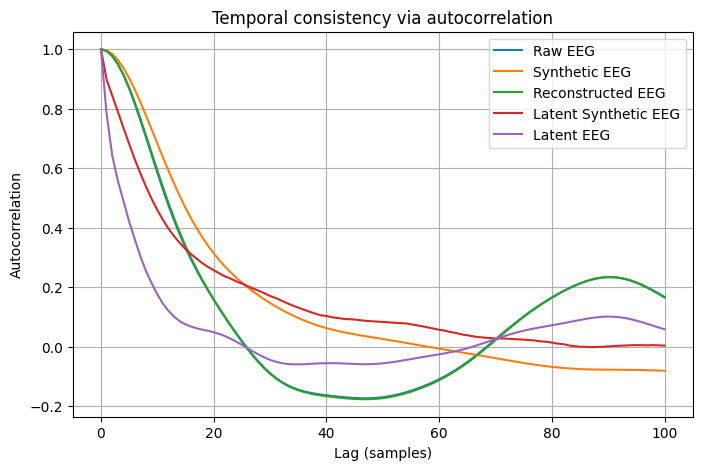

In [ ]:
max_lag = 250

acf_synt   = synthetic_eeg_acf(G, R, 1, device,max_lag)
acf_raw    = raw_eeg_acf(dataloader, max_lag)
acf_recon  = reconstructed_eeg_acf(E, R, dataloader, device, max_lag)
acf_synt_lat = latent_synthetic_eeg_acf(G,device, 1, max_lag)
acf_lat = latent_acf(E, dataloader, device, max_lag)

plt.figure(figsize=(8, 5))
plt.plot(acf_raw, label="Raw EEG")
plt.plot(acf_synt, label="Synthetic EEG")
plt.plot(acf_recon, label="Reconstructed EEG")
plt.plot(acf_synt_lat, label="Latent Synthetic EEG")
plt.plot(acf_lat, label="Latent EEG")

plt.xlabel("Lag (samples)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.title("Temporal consistency via autocorrelation")
plt.grid(True)
plt.show()

In [21]:
def compute_psd(x):
    # x: (N, T)

    X = torch.fft.rfft(x, dim=-1)
    psd = (X.abs() ** 2) / x.shape[-1]

    return psd

In [22]:
@torch.no_grad()
def latent_psd(embedder, dataloader, device):
    embedder.eval()
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        z = embedder(x, y)  # (B, T, D)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)


In [23]:
@torch.no_grad()
def real_psd(dataloader, device):
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)


        B, T, D = x.shape

        # reshape so each latent dimension becomes a signal
        x = x.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(x)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [24]:
@torch.no_grad()
def recon_psd(embedder, recovery, dataloader, device):
    embedder.eval()
    recovery.eval()
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        z, _ = embedder(x, y)  # (B, T, D)
        z = recovery(z, y)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [25]:
@torch.no_grad()
def recon_syn_psd(recovery, generator, label, device):
    recovery.eval()
    generator.eval()

    psds = []

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = NOISE_DIM

    # Generate synthetic batch
    labels = torch.full((B,), label).to(device)
    Z = torch.randn(B, T, z_dim, device=device)
    H_fake = generator(Z, labels)          # (B, T, D_latent)
    labels_orig = torch.full((B,), label+2).to(device)
    X_fake = recovery(H_fake, labels_orig)      # (B, T, D_data)

    B, T, D = X_fake.shape

    # Match real pipeline: treat each dimension as a signal
    X_fake = X_fake.permute(0, 2, 1).reshape(B * D, T)

    # Compute PSD
    psd = compute_psd(X_fake)      # (B*D, F)

    psds.append(psd)

    # Aggregate
    psds = torch.cat(psds)
    return psds.mean(dim=0)

In [26]:
realPSD = real_psd(dataloader, device)
reconPSD = recon_psd(E, R, dataloader, device)
synPSD = recon_syn_psd(R, G, 0, device)

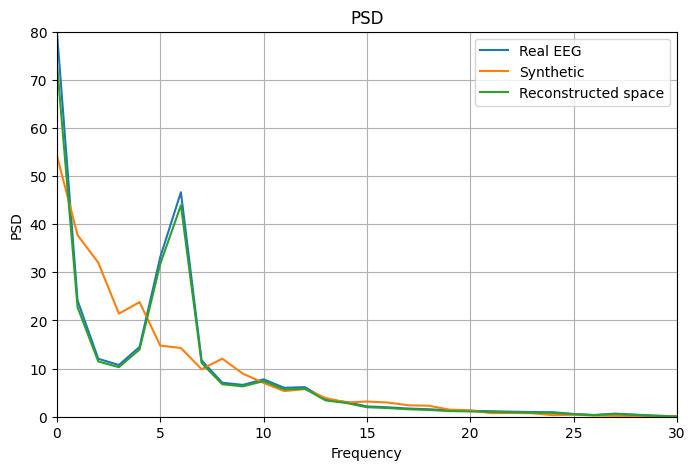

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(realPSD.cpu(), label="Real EEG")
plt.plot(synPSD.cpu(), label="Synthetic")
plt.plot(reconPSD.cpu(), label="Reconstructed space")

plt.axis([0, 30, 0, 80])
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.legend()
plt.title("PSD")
plt.grid(True)
plt.show()
